In [1]:
#|default_exp app

In [2]:
#|export
from fastai.vision.all import *
import gradio as gr

In [3]:
#im = PILImage.create("maserati.jpg")
im = PILImage.create("ferrari.jpg")

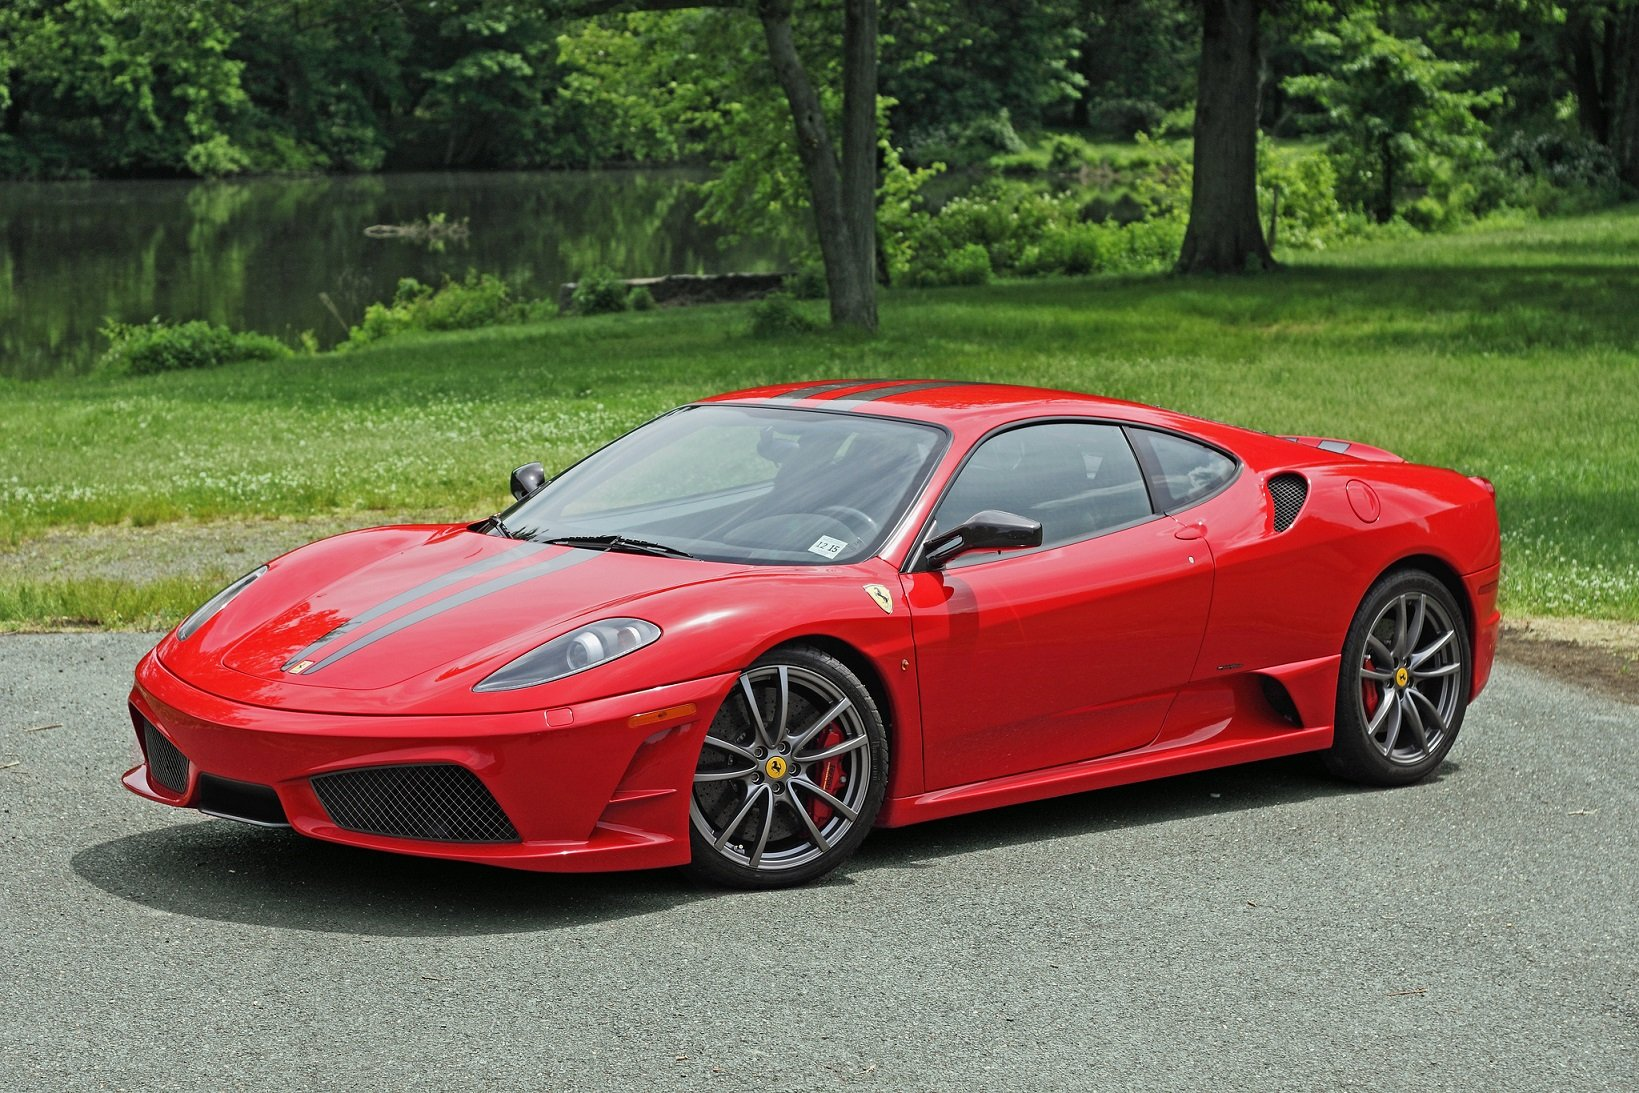

In [4]:
im.to_thumb(128)
im

In [5]:
#|export
learn = load_learner("export.pkl")

In [6]:
learn.predict(im)

('ferrari', tensor(0), tensor([9.9685e-01, 5.3065e-04, 2.6241e-03]))

In [7]:
#formatting outputs for gradio
learn.dls.vocab

['ferrari', 'lamborghini', 'maserati']

In [8]:
list(map(float,learn.predict(im)[2]))

[0.9968453049659729, 0.0005306482780724764, 0.0026240902952849865]

In [9]:
#|export
categories = ("ferrari","lamborghini","maserati")

def classify_images(img):
    pred,probs_idx,probs = learn.predict(img)
    return dict(zip(categories,map(float,probs))) #we need to convert tensors to float for gradio

In [10]:
classify_images(im)

{'ferrari': 0.9968453049659729,
 'lamborghini': 0.0005306482780724764,
 'maserati': 0.0026240902952849865}

In [11]:
#|export
image = gr.Image()
label = gr.Label()
examples=["maserati.jpg","ferrari.jpg"]

intf = gr.Interface(fn=classify_images,inputs=image,outputs=label,examples=examples)
#local run of the app
intf.launch(inline=False)

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


In [12]:
import nbdev

In [13]:
nbdev.export.nb_export("Chap2_InferenceApp_Gradio.ipynb","/Users/vincentkreutz/Documents/Github/fastbook")